In [1]:
                                                    # Подготовка: Импорты и загрузка данных

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from src.fluid import Fluid
from src.reservoir import Reservoir, ResProps
from src.well import Well
from src.pipe import Pipe
from src.simulator import FieldSimulator
from src.compressor import DCS
from scipy.optimize import minimize

# 1. Загрузка индивидуальных данных (Самохвалов Д.А.)
hw2_df = pd.read_csv('hw2_data.csv', sep=';', index_col=0)
my_data = hw2_df[hw2_df['student'].str.contains("Самохвалов")].iloc[0]

# 2. Загрузка данных вязкости
interp_df = pd.read_csv('interp_data.csv', sep=';')
visc_p = interp_df['pressure, atm'].tolist()
visc_mu = interp_df['viscosity, cP'].tolist()

# 3. Инициализация PVT-модели
fluid = Fluid(
    t_res=310,
    p_std_kgm3=my_data['rho_c, kg/m3'],
    xa_pct=my_data['xa, mol. %'],
    xy_pct=my_data['xy, mol. %'],
    visc_data_x=visc_p,
    visc_data_y=visc_mu
)

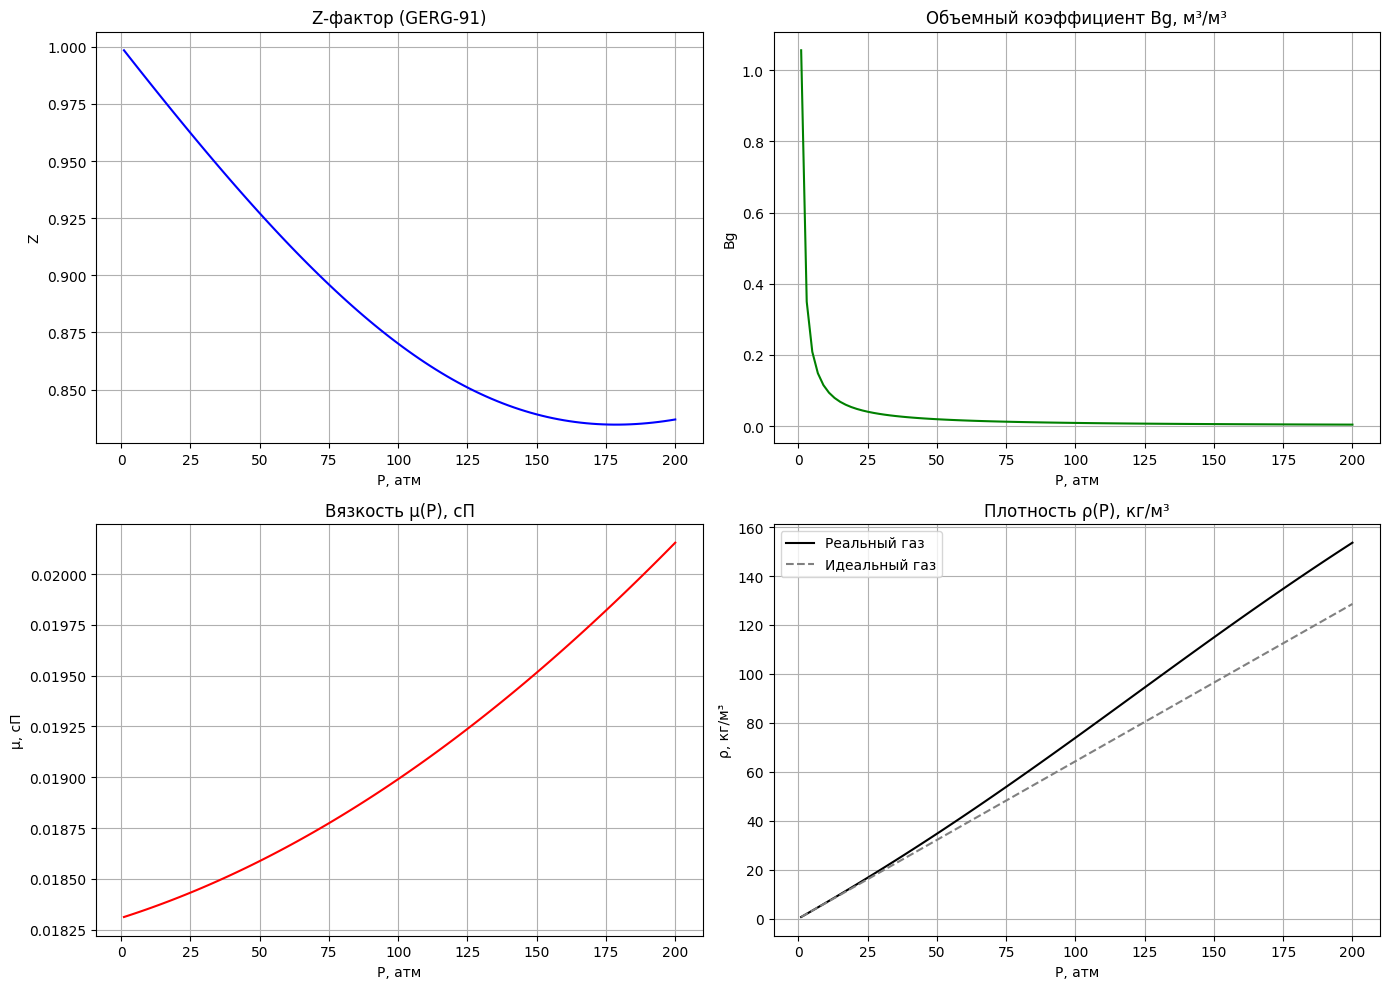

Плотность при 100 атм: 73.89 кг/м3 (Ожидается ~67-74)
Bg при 100 атм: 0.00920 м3/м3 (Ожидается ~0.009)


In [2]:
                                                            #Раздел 1. PVT-модель

#Согласно ТЗ: графики Z, Bg, mu в диапазоне 1–200 атм и сравнение плотностей

p_range = np.linspace(1, 200, 100)
z_factors = [fluid.get_z(p) for p in p_range]
bg_factors = [fluid.get_bg(p) for p in p_range]
viscosities = [fluid.get_mu(p) for p in p_range]
rho_real = [fluid.get_rho(p) for p in p_range]

# Расчет плотности идеального газа (Z=1)
r_const, t_res = 8.314, 310
rho_ideal = [(p * 101325 * fluid.M) / (r_const * t_res) for p in p_range]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# (0, 0) — Z-фактор
axs[0, 0].plot(p_range, z_factors, color='blue')
axs[0, 0].set_title('Z-фактор (GERG-91)')
axs[0, 0].set_xlabel('P, атм')
axs[0, 0].set_ylabel('Z')
axs[0, 0].grid(True)

# (0, 1) — Bg
axs[0, 1].plot(p_range, bg_factors, color='green')
axs[0, 1].set_title('Объемный коэффициент Bg, м³/м³')
axs[0, 1].set_xlabel('P, атм')
axs[0, 1].set_ylabel('Bg')
axs[0, 1].grid(True)

# (1, 0) — вязкость
axs[1, 0].plot(p_range, viscosities, color='red')
axs[1, 0].set_title('Вязкость μ(P), сП')
axs[1, 0].set_xlabel('P, атм')
axs[1, 0].set_ylabel('μ, сП')
axs[1, 0].grid(True)

# (1, 1) — плотность: реальный vs идеальный
axs[1, 1].plot(p_range, rho_real, label='Реальный газ', color='black')
axs[1, 1].plot(p_range, rho_ideal, '--', label='Идеальный газ', color='gray')
axs[1, 1].set_title('Плотность ρ(P), кг/м³')
axs[1, 1].set_xlabel('P, атм')
axs[1, 1].set_ylabel('ρ, кг/м³')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Самопроверка (раздел 5 ТЗ)
print(f"Плотность при 100 атм: {fluid.get_rho(100):.2f} кг/м3 (Ожидается ~67-74)")
print(f"Bg при 100 атм: {fluid.get_bg(100):.5f} м3/м3 (Ожидается ~0.009)")

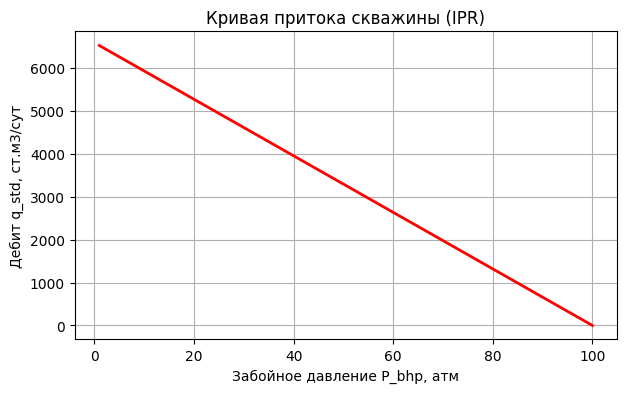

Давление через 30 дней (при q=3000): 100.0000 атм (Падение: 0.0000)


In [3]:
                                                # Раздел 2. Модель пласта и притока (IPR)

# Инициализация "бака" и кривая притока

# 2.1 Инициализация пласта
res_props = ResProps(p=100, v_res=math.pi * 500**2 * 25, t_res=310)
reservoir = Reservoir(props=res_props, fluid=fluid)

# 2.2 Инициализация скважины 1 
well_1 = Well(k_md=50, h_m=25.0, re_m=500, rw_m=0.1, fluid=fluid)

# 2.3 Построение IPR (при P_res = 100 атм) 
p_bhp_range = np.linspace(1, 100, 50)
q_ipr = [well_1.q_std(100, p) for p in p_bhp_range]

plt.figure(figsize=(7, 4))
plt.plot(p_bhp_range, q_ipr, color='red', lw=2)
plt.title('Кривая притока скважины (IPR)')
plt.xlabel('Забойное давление P_bhp, атм'); plt.ylabel('Дебит q_std, ст.м3/сут'); plt.grid(True); plt.show()

# Тест материального баланса (метод p2) 
p_next = reservoir.p2(q_total_std=3000, dt=30) # тест с большим дебитом для наглядности
print(f"Давление через 30 дней (при q=3000): {p_next:.4f} атм (Падение: {100 - p_next:.4f})")

Коэффициент λ при Re=1e5: 0.0211 (Ожидается ~0.019-0.021)


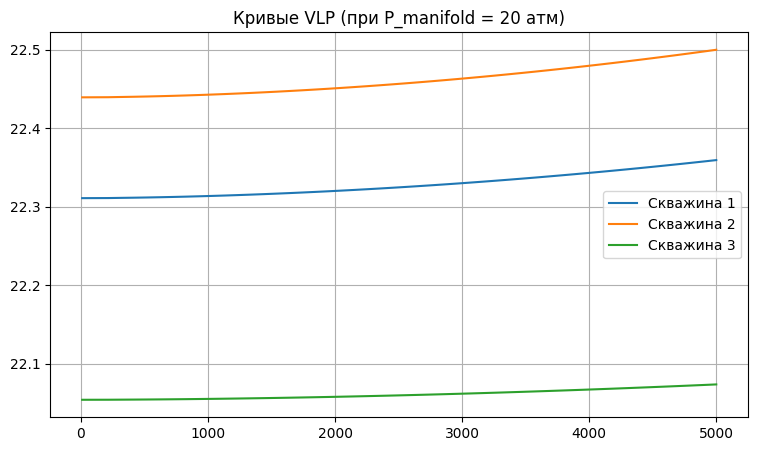

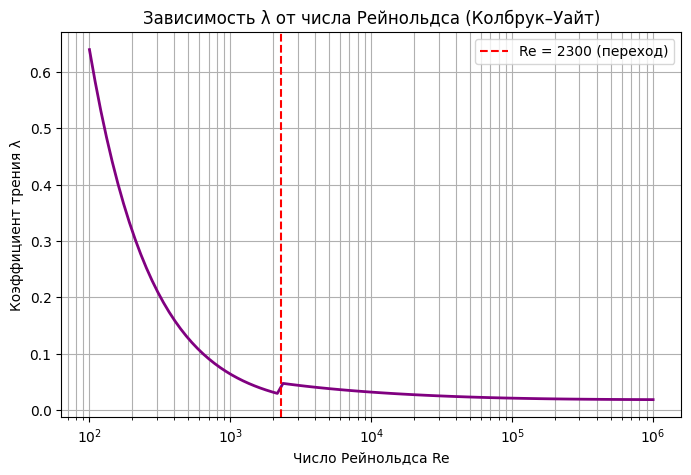

In [4]:
                                                        # Раздел 3. Гидравлика (VLP)

# Проверка Colebrook-White и кривые подъема для всех труб

# 3.1 Тест коэффициента трения (Раздел 5 ТЗ) 
test_pipe = Pipe(l_m=1000, d_m=0.062, vertical_depth_m=1000, roughness_m=0.0000434, fluid=fluid)
print(f"Коэффициент λ при Re=1e5: {test_pipe._get_lambda(1e5):.4f} (Ожидается ~0.019-0.021)")

# 3.2 Создание труб системы (Таблица 4) 
pipes = [
    Pipe(2000, 0.062, 1800, 0.000046, fluid), # НКТ 1
    Pipe(2500, 0.062, 1900, 0.000046, fluid), # НКТ 2
    Pipe(1800, 0.073, 1600, 0.000046, fluid), # НКТ 3
    Pipe(5000, 0.200, 0.0, 0.000046, fluid)    # Шлейф
]

# 3.3 Построение VLP 
q_vlp_range = np.linspace(10, 5000, 50)
plt.figure(figsize=(9, 5))
for i in range(3):
    vlp = [20 + (pipes[i].dp(q, 20).p_in - pipes[i].dp(q, 20).p_out) for q in q_vlp_range]
    plt.plot(q_vlp_range, vlp, label=f'Скважина {i+1}')
plt.title('Кривые VLP (при P_manifold = 20 атм)'); plt.legend(); plt.grid(True); plt.show()

# 3.4 График зависимости коэффициента трения от числа Рейнольдса
pipe_ref = pipes[0]

re_range = np.logspace(2, 6, 100)  # от 100 до 1000000
lambdas = [pipe_ref._get_lambda(re) for re in re_range]

plt.figure(figsize=(8, 5))
plt.plot(re_range, lambdas, color='purple', lw=2)
plt.xscale('log')
plt.title('Зависимость λ от числа Рейнольдса (Колбрук–Уайт)')
plt.xlabel('Число Рейнольдса Re')
plt.ylabel('Коэффициент трения λ')
plt.axvline(2300, color='red', linestyle='--', label='Re = 2300 (переход)')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

Начальный дебит куста: 18951.28 ст.м3/сут
Шаг 0/180: P_res = 100.00 атм
Шаг 10/180: P_res = 100.00 атм
Шаг 20/180: P_res = 100.00 атм
Шаг 30/180: P_res = 100.00 атм
Шаг 40/180: P_res = 100.00 атм
Шаг 50/180: P_res = 100.00 атм
Шаг 60/180: P_res = 100.00 атм
Шаг 70/180: P_res = 100.00 атм
Шаг 80/180: P_res = 100.00 атм
Шаг 90/180: P_res = 100.00 атм
Шаг 100/180: P_res = 100.00 атм
Шаг 110/180: P_res = 100.00 атм
Шаг 120/180: P_res = 100.00 атм
Шаг 130/180: P_res = 100.00 атм
Шаг 140/180: P_res = 100.00 атм
Шаг 150/180: P_res = 100.00 атм
Шаг 160/180: P_res = 100.00 атм
Шаг 170/180: P_res = 100.00 атм


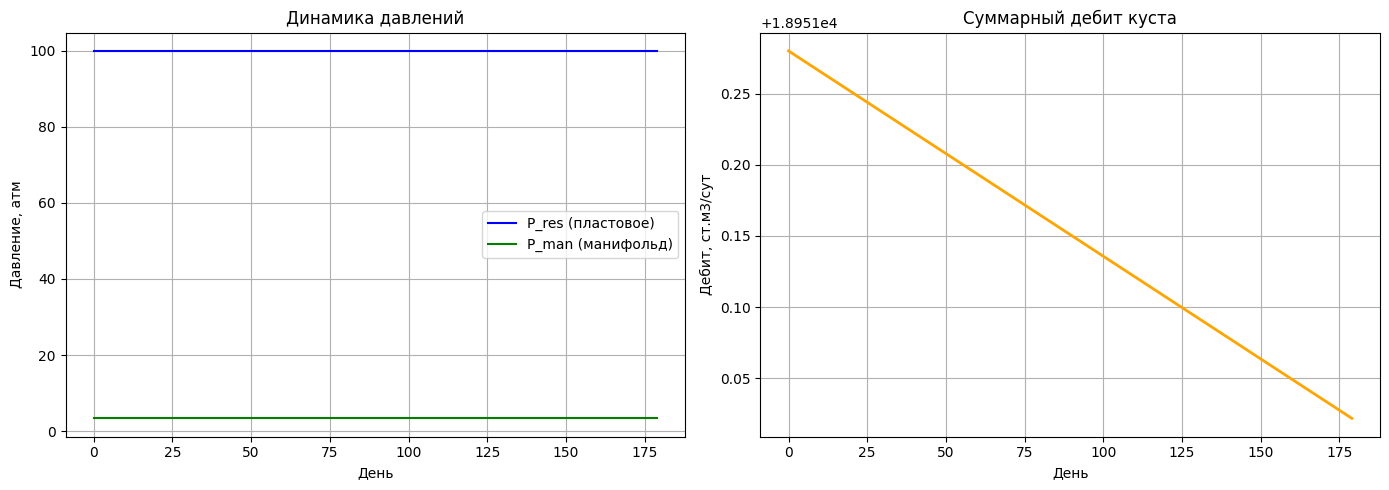

Давление в конце симуляции: 99.9986 атм


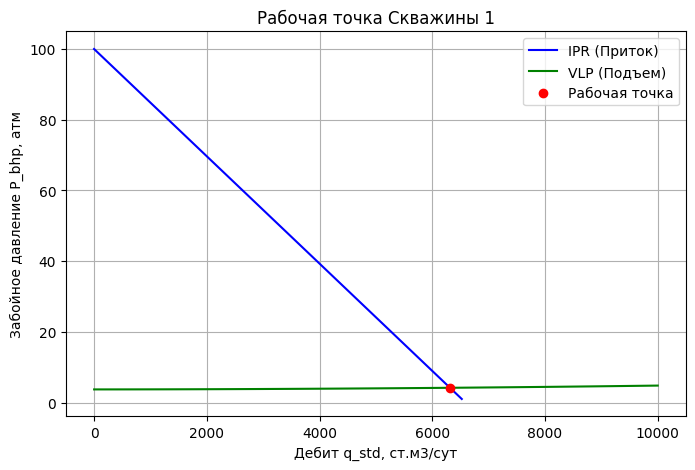

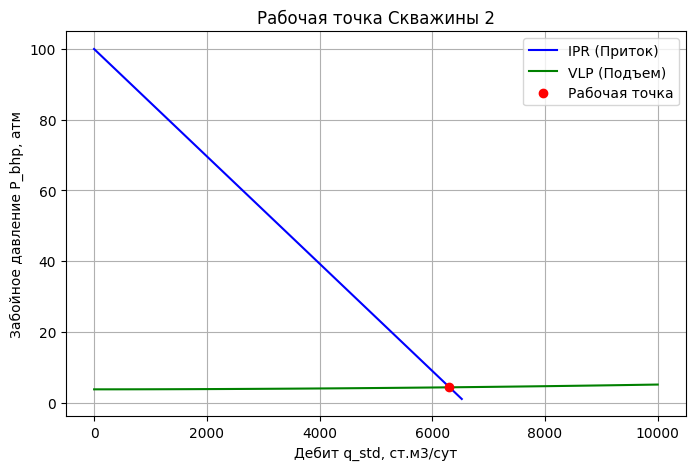

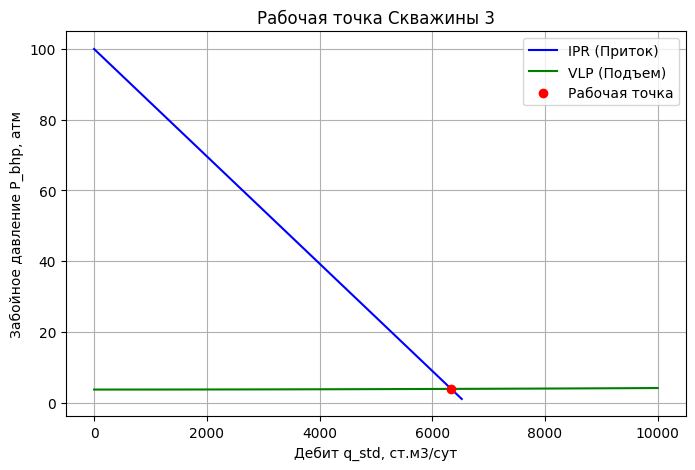

Шаг 0/180: P_res = 100.00 атм
Шаг 10/180: P_res = 100.00 атм
Шаг 20/180: P_res = 100.00 атм
Шаг 30/180: P_res = 100.00 атм
Шаг 40/180: P_res = 100.00 атм
Шаг 50/180: P_res = 100.00 атм
Шаг 60/180: P_res = 100.00 атм
Шаг 70/180: P_res = 100.00 атм
Шаг 80/180: P_res = 100.00 атм
Шаг 90/180: P_res = 100.00 атм
Шаг 100/180: P_res = 100.00 атм
Шаг 110/180: P_res = 100.00 атм
Шаг 120/180: P_res = 100.00 атм
Шаг 130/180: P_res = 100.00 атм
Шаг 140/180: P_res = 100.00 атм
Шаг 150/180: P_res = 100.00 атм
Шаг 160/180: P_res = 100.00 атм
Шаг 170/180: P_res = 100.00 атм


In [5]:
                                                    # Раздел 4. Рабочая точка и Динамика

# Объединение в симулятор и расчет на 180 дней

# 4.1 Инициализация ДКС и Симулятора 
dcs = DCS(p_line=5, cr=1.5, q_ext=500)
simulator = FieldSimulator(reservoir, [well_1]*3, pipes[:3], pipes[3], dcs)

# 4.2 Поиск рабочей точки
sol_state = simulator.solve()
print(f"Начальный дебит куста: {sum(sol_state[f'well_{i+1}'].q_std for i in range(3)):.2f} ст.м3/сут")

# 4.3 Запуск динамики на 180 дней 
history = simulator.run(n_days=180, dt=1)
df_dyn = pd.DataFrame(history)

# 4.4 Визуализация динамики 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: Давления
ax1.plot(df_dyn['day'], df_dyn['p_res'], label='P_res (пластовое)', color='blue')
ax1.plot(df_dyn['day'], df_dyn['p_man'], label='P_man (манифольд)', color='green')
ax1.set_title('Динамика давлений')
ax1.set_xlabel('День')  
ax1.set_ylabel('Давление, атм')
ax1.legend()
ax1.grid(True)

# Правый график: Дебит
ax2.plot(df_dyn['day'], df_dyn['q_total'], color='orange', lw=2)
ax2.set_title('Суммарный дебит куста')
ax2.set_xlabel('День')
ax2.set_ylabel('Дебит, ст.м3/сут')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Давление в конце симуляции: {df_dyn['p_res'].iloc[-1]:.4f} атм")

# Построение графиков для рабочих точек скважин

def plot_well_operating_point(well_idx, simulator, solved_states):
    well_key = f'well_{well_idx+1}'
    p_res = simulator.reservoir.props.p
    p_man = solved_states['shlyf'].p_in # Давление на манифольде из решения
    
    q_arr = np.linspace(1, 10000, 50) # Диапазон дебитов для графиков
    
    # 1. Линия притока (IPR): q(P_bhp)
    p_bhp_ipr = np.linspace(1, p_res, 50)
    q_ipr = [simulator.wells[well_idx].q_std(p_res, p) for p in p_bhp_ipr]
    
    # 2. Линия подъема (VLP): P_bhp(q) = P_man + Delta_P_tube
    vlp_p_bhp = []
    for q in q_arr:
        state_well = simulator.well_pipes[well_idx].dp(q, p_man)
        vlp_p_bhp.append(p_man + (state_well.p_in - state_well.p_out))
        
    plt.figure(figsize=(8, 5))
    plt.plot(q_ipr, p_bhp_ipr, label='IPR (Приток)', color='blue')
    plt.plot(q_arr, vlp_p_bhp, label='VLP (Подъем)', color='green')
    
    # 3. Отмечаем найденную рабочую точку
    q_point = solved_states[well_key].q_std
    p_bhp_point = p_man + (solved_states[well_key].p_in - solved_states[well_key].p_out)
    plt.scatter([q_point], [p_bhp_point], color='red', zorder=5, label='Рабочая точка')
    
    plt.title(f'Рабочая точка Скважины {well_idx+1}')
    plt.xlabel('Дебит q_std, ст.м3/сут')
    plt.ylabel('Забойное давление P_bhp, атм')
    plt.grid(True)
    plt.legend()
    plt.show()

# Построение графиков для всех трех скважин
for i in range(3):
    plot_well_operating_point(i, simulator, sol_state)

# Симуляция 180 дней
history = simulator.run(n_days=180, dt=1)
df_dyn = pd.DataFrame(history)


--- Расчет для CR = 1 ---
Шаг 0/180: P_res = 100.00 атм
Шаг 10/180: P_res = 100.00 атм
Шаг 20/180: P_res = 100.00 атм
Шаг 30/180: P_res = 100.00 атм
Шаг 40/180: P_res = 100.00 атм
Шаг 50/180: P_res = 100.00 атм
Шаг 60/180: P_res = 100.00 атм
Шаг 70/180: P_res = 100.00 атм
Шаг 80/180: P_res = 100.00 атм
Шаг 90/180: P_res = 100.00 атм
Шаг 100/180: P_res = 100.00 атм
Шаг 110/180: P_res = 100.00 атм
Шаг 120/180: P_res = 100.00 атм
Шаг 130/180: P_res = 100.00 атм
Шаг 140/180: P_res = 100.00 атм
Шаг 150/180: P_res = 100.00 атм
Шаг 160/180: P_res = 100.00 атм
Шаг 170/180: P_res = 100.00 атм

--- Расчет для CR = 1.5 ---
Шаг 0/180: P_res = 100.00 атм
Шаг 10/180: P_res = 100.00 атм
Шаг 20/180: P_res = 100.00 атм
Шаг 30/180: P_res = 100.00 атм
Шаг 40/180: P_res = 100.00 атм
Шаг 50/180: P_res = 100.00 атм
Шаг 60/180: P_res = 100.00 атм
Шаг 70/180: P_res = 100.00 атм
Шаг 80/180: P_res = 100.00 атм
Шаг 90/180: P_res = 100.00 атм
Шаг 100/180: P_res = 100.00 атм
Шаг 110/180: P_res = 100.00 атм
Шаг 12

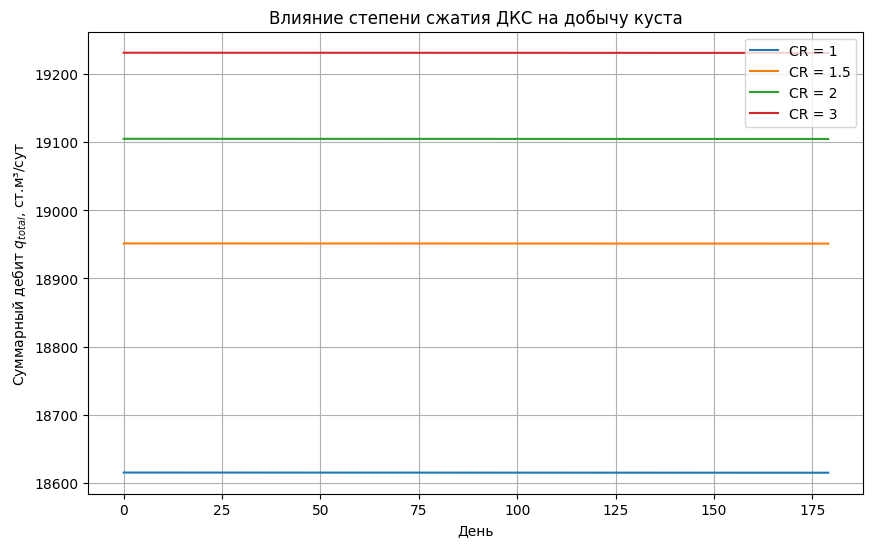

In [6]:
                                                # Раздел 5. Влияение ДКС (Анализ чувствительности CR)
# # Согласно ТЗ: сравнение CR = 1, 1.5, 2, 3
plt.figure(figsize=(10, 6))

for cr_val in [1, 1.5, 2, 3]:
    # Сбрасываем давление пласта для каждого теста, чтобы условия были равными
    reservoir.props.p = 100
    dcs.cr = cr_val
    
    # Инициализируем симулятор с новым значением CR
    sim_cr = FieldSimulator(reservoir, [well_1]*3, pipes[:3], pipes[3], dcs)
    
    print(f"\n--- Расчет для CR = {cr_val} ---")
    hist_cr = sim_cr.run(n_days=180, dt=1)
    df_cr = pd.DataFrame(hist_cr)
    
    # Строим кривую и добавляем метку для легенды
    plt.plot(df_cr['day'], df_cr['q_total'], label=f'CR = {cr_val}')

# Оформление графика
plt.title('Влияние степени сжатия ДКС на добычу куста')
plt.xlabel('День')
plt.ylabel('Суммарный дебит $q_{total}$, ст.м³/сут')
plt.legend()
plt.grid(True, which="both", ls="-") 
plt.show()

--- Результаты калибровки ---
Оптимальный коэффициент C: 23230.26
Минимальный RMSE: 2499.69 ст.м3/сут
Коэффициент детерминации R2: 0.9709


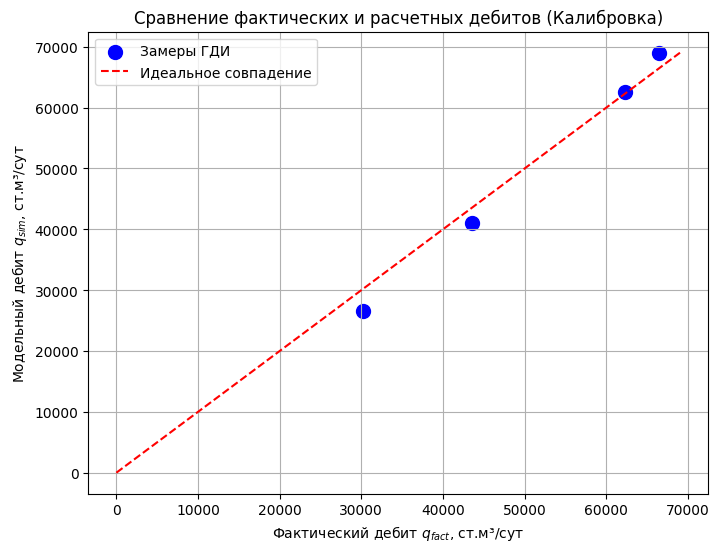

In [7]:
                                         # Раздел 6. Калибровка модели
# Загрузка данных калибровки
df_adapt = pd.read_csv('adapt_gdi_11-2025.csv', sep=',')

# Выделим фактические данные для удобства
q_fact = df_adapt['q'].values
p_res_fact = df_adapt['p_res'].values
p_bhp_fact = df_adapt['p_bhp'].values

# Определение целевой функции RMSE
def rmse_objective(c_param):
    
    # Расчет модельных дебитов для каждого замера
    q_sim = c_param * (p_res_fact - p_bhp_fact)
    
    # Расчет RMSE по формуле из ТЗ
    mse = np.mean((q_sim - q_fact)**2)
    return np.sqrt(mse)

# Минимизация ошибки для поиска оптимального C

res_opt = minimize(rmse_objective, x0=[1000.0], method='Nelder-Mead')
c_opt = res_opt.x[0] #Извлечение скаляра после оптимизаци

# Расчет метрик качества
q_final_sim = c_opt * (p_res_fact - p_bhp_fact)
rmse_final = res_opt.fun

# Расчет R2
ss_res = np.sum((q_fact - q_final_sim)**2)
ss_tot = np.sum((q_fact - np.mean(q_fact))**2)
r2_score = 1 - (ss_res / ss_tot)

print(f"--- Результаты калибровки ---")
print(f"Оптимальный коэффициент C: {c_opt:.2f}")
print(f"Минимальный RMSE: {rmse_final:.2f} ст.м3/сут")
print(f"Коэффициент детерминации R2: {r2_score:.4f}")

# Визуализация «Факт vs Модель»
plt.figure(figsize=(8, 6))
plt.scatter(q_fact, q_final_sim, color='blue', label='Замеры ГДИ', s=100)

# Линия идеального совпадения (45 градусов)
max_q = max(q_fact.max(), q_final_sim.max())
plt.plot([0, max_q], [0, max_q], '--', color='red', label='Идеальное совпадение')

plt.title('Сравнение фактических и расчетных дебитов (Калибровка)')
plt.xlabel('Фактический дебит $q_{fact}$, ст.м³/сут')
plt.ylabel('Модельный дебит $q_{sim}$, ст.м³/сут')
plt.legend()
plt.grid(True)
plt.show()